# Dental Caries Staging — Multi-Seed Robustness Follow-Up (Deduplicated)

This notebook extends `Dental_Heatmap_Fixed.ipynb` and fixes a data-quality issue found by
auditing the dataset zip directly.

**What this notebook adds on top of the multi-seed version:**
0. **Deduplication.** The dataset zip contains 11 groups of exact byte-identical duplicate
   images (23 files total, all within `NoEnamel_Caries/[Originals]/`). Left unfixed,
   `random_split` can place a duplicate pair on opposite sides of the train/test boundary,
   letting the model "recognize" a memorized training image at test time rather than
   generalizing -- inflating accuracy for that class. This notebook hashes every image and
   excludes redundant copies **before** any split is constructed (see the Deduplication
   section below), so every seed's split operates on a clean, duplicate-free dataset.
1. **N repeated runs per model**, each with a different random seed that controls the
   data split *and* model initialization/training stochasticity together (so both sources
   of variance are captured, not just weight init).
2. **Mean ± standard deviation** for accuracy, macro precision/recall/F1, and macro AUROC
   per model, instead of a single point estimate.
3. **Paired statistical significance testing** (paired t-test across seeds) between every
   pair of models, so "ResNet-50 vs. ViT-B/16" or "DenseNet-121 vs. SqueezeNet 1.1" can be
   backed by a p-value rather than eyeballed from a table.
4. **Confusion matrices** for all four models (primary seed), row-normalized with raw counts
   annotated, to make the Advanced-vs-Early-Stage confusion pattern discussed in the paper
   directly visible rather than only described in prose.
5. The qualitative **Grad-CAM / attention-rollout explainability figures** are kept, generated
   once from the primary seed (the first entry in `SEEDS`) to avoid needing N complete sets
   of explainability figures.

**Runtime note:** with the default `SEEDS = [42, 123, 2024, 7, 1000]` (5 seeds), this trains
4 models × 5 seeds = 20 full 15-epoch runs. On a Colab T4 GPU this can take roughly 2–3 hours
total. If you're time-constrained, trim `SEEDS` to 3 values (e.g. `[42, 123, 2024]`) —
everything below works unchanged with any number of seeds ≥ 2.

**Compare against your previous (non-deduplicated) multi-seed results** once this finishes --
if the No-Caries class metrics or overall accuracy shift noticeably, that's the leak's effect
becoming visible.

In [ ]:
# 1. Unzip dataset
import zipfile
import os

zip_file_path = '/content/Caries_Dataset.zip'
extract_dir = '/content/Caries_Dataset_extracted/'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")

'/content/Caries_Dataset.zip' unzipped to '/content/Caries_Dataset_extracted/' successfully.


In [ ]:
# 2. Global configuration
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using execution device: {device}")

DATA_DIR = '/content/Caries_Dataset_extracted'
CLASS_NAMES = ['AdvanceEnamel_Caries', 'EarlyStageEnamel_Caries', 'NoEnamel_Caries']
MODEL_LIST = ['ResNet-50', 'DenseNet-121', 'ViT-B/16', 'SqueezeNet 1.1']

# Each seed controls BOTH the data split and model init/training stochasticity for that run,
# so repeated-seed variance reflects total run-to-run variability, not just weight init.
SEEDS = [42, 123, 2024, 7, 1000]
PRIMARY_SEED = SEEDS[0]  # used for the qualitative Grad-CAM / attention-rollout figures

full_dataset_raw = datasets.ImageFolder(root=DATA_DIR)
print(f"Class-to-index mapping: {full_dataset_raw.class_to_idx}")
print(f"Total images (before deduplication): {len(full_dataset_raw)}")

Using execution device: cuda:0
Class-to-index mapping: {'AdvanceEnamel_Caries': 0, 'EarlyStageEnamel_Caries': 1, 'NoEnamel_Caries': 2}
Total images (before deduplication): 2234


## Deduplication

A manual audit of the dataset zip found **11 groups of exact byte-identical duplicate
images (23 files total)**, all inside `NoEnamel_Caries/[Originals]/` -- e.g.
`NoEnamel_Caries_078.jpg` and `NoEnamel_Caries_079.jpg` are literally the same file. Left
unaddressed, `random_split` has no notion of duplicate content, so a duplicate pair can land
on opposite sides of the train/test boundary. When that happens the model isn't generalizing
to that test image, it's recognizing a training image it already memorized byte-for-byte --
silently inflating accuracy for the affected class (No Enamel Caries, which was already the
near-ceiling class in every prior run).

The cell below hashes every image, keeps exactly one representative copy per duplicate
group, and excludes the rest **before** any split is constructed, so the leak is fixed at
the source rather than patched per-seed.

In [ ]:
# 3. Deduplicate the dataset by exact file content (MD5) before any split is created.
import hashlib
from pathlib import Path
from collections import defaultdict

def file_md5(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

image_paths = [Path(p) for p, _ in full_dataset_raw.samples]
hash_to_paths = defaultdict(list)
for p in image_paths:
    hash_to_paths[file_md5(p)].append(p)

duplicate_groups = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
n_duplicate_files = sum(len(v) for v in duplicate_groups.values())
print(f"Found {len(duplicate_groups)} duplicate groups covering {n_duplicate_files} files "
      f"({n_duplicate_files - len(duplicate_groups)} redundant copies to exclude).")

EXCLUDED_PATHS = set()
for h, paths in duplicate_groups.items():
    kept, *extras = sorted(str(p) for p in paths)
    EXCLUDED_PATHS.update(extras)
    print(f"  keeping {kept}  |  excluding {extras}")

keep_indices = [i for i, (path, _) in enumerate(full_dataset_raw.samples) if path not in EXCLUDED_PATHS]
print(f"\nDataset after deduplication: {len(keep_indices)} images "
      f"(was {len(full_dataset_raw)}, removed {len(full_dataset_raw) - len(keep_indices)}).")

# Wrap as a Subset so every downstream cell (make_split, make_class_weights, Grad-CAM image
# lookup, etc.) transparently operates on the deduplicated set with no other code changes.
full_dataset = torch.utils.data.Subset(full_dataset_raw, keep_indices)
full_dataset.targets = [full_dataset_raw.targets[i] for i in keep_indices]
full_dataset.classes = full_dataset_raw.classes
full_dataset.class_to_idx = full_dataset_raw.class_to_idx

dedup_counts = np.bincount([full_dataset_raw.targets[i] for i in keep_indices], minlength=len(CLASS_NAMES))
print(f"Post-dedup class counts: {dict(zip(full_dataset_raw.classes, dedup_counts))}")

Found 11 duplicate groups covering 23 files (12 redundant copies to exclude).
  keeping /content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_078.jpg  |  excluding ['/content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_079.jpg']
  keeping /content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_081.jpg  |  excluding ['/content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_082.jpg']
  keeping /content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_090.jpg  |  excluding ['/content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_091.jpg']
  keeping /content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_092.jpg  |  excluding ['/content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_093.jpg', '/content/Caries_Dataset_extracted/NoEnamel_Caries/[Originals]/NoEnamel_Caries_095.jpg']
  keeping /content/Caries_Dataset

In [ ]:
# 4. Reusable split / loader / class-weight construction, parameterized by seed

class TransformedDataset(Dataset):
    # Wraps a Subset of the untransformed ImageFolder with a model-specific transform.
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


def make_split(seed):
    n_total = len(full_dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val
    generator = torch.Generator().manual_seed(seed)
    return random_split(full_dataset, [n_train, n_val, n_test], generator=generator)


def make_class_weights(train_subset):
    train_targets = [full_dataset.targets[i] for i in train_subset.indices]
    counts = np.bincount(train_targets, minlength=len(CLASS_NAMES))
    total = sum(counts)
    weights = torch.FloatTensor([total / c for c in counts]).to(device)
    return weights, counts


def make_loaders(resolution, train_subset, val_subset, test_subset, batch_size=16, num_workers=2):
    train_transform = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    train_loader = DataLoader(TransformedDataset(train_subset, train_transform),
                               batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(TransformedDataset(val_subset, eval_transform),
                             batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(TransformedDataset(test_subset, eval_transform),
                              batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader


RESOLUTION_BY_MODEL = {
    'ResNet-50': 384,
    'DenseNet-121': 384,
    'ViT-B/16': 224,
    'SqueezeNet 1.1': 224,
}

In [ ]:
# 5. Model factory -- encapsulates each architecture's fine-tuning recipe (matching the
# single-run notebook's final, corrected hyperparameters) so it can be rebuilt fresh per seed.

def build_model_and_optimizer(model_name, device):
    if model_name == 'ResNet-50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for name, child in model.named_children():
            requires_grad = name in ['layer4', 'fc']
            for param in child.parameters():
                param.requires_grad = requires_grad
        model.fc = nn.Linear(model.fc.in_features, 3)
        model = model.to(device)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    elif model_name == 'DenseNet-121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        for name, param in model.named_parameters():
            param.requires_grad = (name.startswith('features.denseblock4')
                                    or name.startswith('features.norm5')
                                    or name.startswith('classifier'))
        model.classifier = nn.Linear(model.classifier.in_features, 3)
        model = model.to(device)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    elif model_name == 'ViT-B/16':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        for name, param in model.named_parameters():
            param.requires_grad = (name.startswith('encoder.layers.encoder_layer_11')
                                    or name.startswith('encoder.ln')
                                    or name.startswith('heads'))
        model.heads.head = nn.Linear(model.heads.head.in_features, 3)
        model = model.to(device)
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=0.01)

    elif model_name == 'SqueezeNet 1.1':
        model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = True  # fully fine-tuned (see notebook 2's finding that
                                         # a frozen-backbone variant underperformed)
        model.classifier[1] = nn.Conv2d(512, 3, kernel_size=(1, 1), stride=(1, 1))
        model.num_classes = 3
        model = model.to(device)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    return model, optimizer, scheduler


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [ ]:
# 6. Training / evaluation loop (unchanged logic from the single-run notebook)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, run_label):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            dataloader = train_loader if phase == 'train' else val_loader

            running_loss, running_corrects, n_seen = 0.0, 0, 0
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                n_seen += inputs.size(0)

            epoch_loss = running_loss / n_seen
            epoch_acc = (running_corrects.double() / n_seen).item()
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            if phase == 'val':
                scheduler.step(epoch_loss)

        print(f"[{run_label}] Epoch {epoch + 1}/{num_epochs} | "
              f"train_loss={history['train_loss'][-1]:.4f} val_loss={history['val_loss'][-1]:.4f} "
              f"val_acc={history['val_acc'][-1]:.4f}")
    return history


def evaluate_model(model, dataloader, class_names, run_label=""):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
    all_labels_one_hot = np.eye(len(class_names))[all_labels]
    try:
        macro_auroc = roc_auc_score(all_labels_one_hot, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        macro_auroc = np.nan

    print(f"[{run_label}] Test accuracy={report_dict['accuracy']:.4f} "
          f"macro_F1={report_dict['macro avg']['f1-score']:.4f} macro_AUROC={macro_auroc:.4f}")

    return {
        'accuracy': report_dict['accuracy'],
        'precision_macro': report_dict['macro avg']['precision'],
        'recall_macro': report_dict['macro avg']['recall'],
        'f1_macro': report_dict['macro avg']['f1-score'],
        'auroc_macro': macro_auroc,
    }

In [ ]:
# 7. MAIN MULTI-SEED LOOP
# Trains all 4 models for each seed in SEEDS. Models/loaders from the PRIMARY_SEED run are
# kept in `primary_models` / `primary_test_loaders` for the explainability figures below.

all_results = []          # one row per (seed, model)
primary_models = {}       # model_name -> trained model object, from PRIMARY_SEED only
primary_test_loaders = {} # model_name -> test_loader, from PRIMARY_SEED only
primary_histories = {}    # model_name -> training history, from PRIMARY_SEED only

for seed in SEEDS:
    print(f"\n{'=' * 70}\nSEED {seed}\n{'=' * 70}")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    train_subset, val_subset, test_subset = make_split(seed)
    class_weights_tensor, train_counts = make_class_weights(train_subset)
    print(f"Split sizes -> train={len(train_subset)} val={len(val_subset)} test={len(test_subset)} "
          f"| train class counts={train_counts}")

    for model_name in MODEL_LIST:
        run_label = f"{model_name} | seed {seed}"
        resolution = RESOLUTION_BY_MODEL[model_name]
        train_loader, val_loader, test_loader = make_loaders(resolution, train_subset, val_subset, test_subset)

        model, optimizer, scheduler = build_model_and_optimizer(model_name, device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                               num_epochs=15, run_label=run_label)
        metrics = evaluate_model(model, test_loader, CLASS_NAMES, run_label=run_label)
        total_params, trainable_params = count_parameters(model)

        all_results.append({
            'seed': seed,
            'model': model_name,
            **metrics,
            'total_params': total_params,
            'trainable_params': trainable_params,
        })

        if seed == PRIMARY_SEED:
            primary_models[model_name] = model
            primary_test_loaders[model_name] = test_loader
            primary_histories[model_name] = history

print("\nAll seeds complete.")


SEED 42
Split sizes -> train=1555 val=333 test=334 | train class counts=[552 557 446]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 46.6MB/s]


[ResNet-50 | seed 42] Epoch 1/15 | train_loss=0.7016 val_loss=0.3367 val_acc=0.8709
[ResNet-50 | seed 42] Epoch 2/15 | train_loss=0.3090 val_loss=0.2325 val_acc=0.9099
[ResNet-50 | seed 42] Epoch 3/15 | train_loss=0.2018 val_loss=0.1321 val_acc=0.9429
[ResNet-50 | seed 42] Epoch 4/15 | train_loss=0.1583 val_loss=0.1387 val_acc=0.9550
[ResNet-50 | seed 42] Epoch 5/15 | train_loss=0.1340 val_loss=0.1024 val_acc=0.9580
[ResNet-50 | seed 42] Epoch 6/15 | train_loss=0.1226 val_loss=0.0913 val_acc=0.9670
[ResNet-50 | seed 42] Epoch 7/15 | train_loss=0.1034 val_loss=0.0877 val_acc=0.9700
[ResNet-50 | seed 42] Epoch 8/15 | train_loss=0.0892 val_loss=0.0727 val_acc=0.9730
[ResNet-50 | seed 42] Epoch 9/15 | train_loss=0.0928 val_loss=0.0615 val_acc=0.9730
[ResNet-50 | seed 42] Epoch 10/15 | train_loss=0.0658 val_loss=0.0694 val_acc=0.9670
[ResNet-50 | seed 42] Epoch 11/15 | train_loss=0.0734 val_loss=0.0613 val_acc=0.9730
[ResNet-50 | seed 42] Epoch 12/15 | train_loss=0.0741 val_loss=0.0517 val_

100%|██████████| 30.8M/30.8M [00:00<00:00, 217MB/s]


[DenseNet-121 | seed 42] Epoch 1/15 | train_loss=0.7223 val_loss=0.4776 val_acc=0.8378
[DenseNet-121 | seed 42] Epoch 2/15 | train_loss=0.4001 val_loss=0.2783 val_acc=0.8949
[DenseNet-121 | seed 42] Epoch 3/15 | train_loss=0.2901 val_loss=0.2084 val_acc=0.9219
[DenseNet-121 | seed 42] Epoch 4/15 | train_loss=0.2346 val_loss=0.1531 val_acc=0.9550
[DenseNet-121 | seed 42] Epoch 5/15 | train_loss=0.1976 val_loss=0.1508 val_acc=0.9459
[DenseNet-121 | seed 42] Epoch 6/15 | train_loss=0.1887 val_loss=0.1149 val_acc=0.9580
[DenseNet-121 | seed 42] Epoch 7/15 | train_loss=0.1748 val_loss=0.1048 val_acc=0.9670
[DenseNet-121 | seed 42] Epoch 8/15 | train_loss=0.1598 val_loss=0.1161 val_acc=0.9550
[DenseNet-121 | seed 42] Epoch 9/15 | train_loss=0.1242 val_loss=0.1070 val_acc=0.9640
[DenseNet-121 | seed 42] Epoch 10/15 | train_loss=0.1354 val_loss=0.0746 val_acc=0.9790
[DenseNet-121 | seed 42] Epoch 11/15 | train_loss=0.1191 val_loss=0.0938 val_acc=0.9730
[DenseNet-121 | seed 42] Epoch 12/15 | tr

100%|██████████| 330M/330M [00:04<00:00, 73.8MB/s]


[ViT-B/16 | seed 42] Epoch 1/15 | train_loss=0.6286 val_loss=0.3664 val_acc=0.8529
[ViT-B/16 | seed 42] Epoch 2/15 | train_loss=0.2734 val_loss=0.2413 val_acc=0.9039
[ViT-B/16 | seed 42] Epoch 3/15 | train_loss=0.2062 val_loss=0.1592 val_acc=0.9399
[ViT-B/16 | seed 42] Epoch 4/15 | train_loss=0.1606 val_loss=0.1637 val_acc=0.9219
[ViT-B/16 | seed 42] Epoch 5/15 | train_loss=0.1381 val_loss=0.0996 val_acc=0.9730
[ViT-B/16 | seed 42] Epoch 6/15 | train_loss=0.1153 val_loss=0.1293 val_acc=0.9369
[ViT-B/16 | seed 42] Epoch 7/15 | train_loss=0.0946 val_loss=0.1603 val_acc=0.9279
[ViT-B/16 | seed 42] Epoch 8/15 | train_loss=0.0906 val_loss=0.0786 val_acc=0.9670
[ViT-B/16 | seed 42] Epoch 9/15 | train_loss=0.0861 val_loss=0.0770 val_acc=0.9730
[ViT-B/16 | seed 42] Epoch 10/15 | train_loss=0.0741 val_loss=0.0692 val_acc=0.9760
[ViT-B/16 | seed 42] Epoch 11/15 | train_loss=0.0659 val_loss=0.0612 val_acc=0.9730
[ViT-B/16 | seed 42] Epoch 12/15 | train_loss=0.0700 val_loss=0.0582 val_acc=0.9820
[

100%|██████████| 4.73M/4.73M [00:00<00:00, 176MB/s]


[SqueezeNet 1.1 | seed 42] Epoch 1/15 | train_loss=0.8313 val_loss=0.5283 val_acc=0.7778
[SqueezeNet 1.1 | seed 42] Epoch 2/15 | train_loss=0.4001 val_loss=0.2484 val_acc=0.8979
[SqueezeNet 1.1 | seed 42] Epoch 3/15 | train_loss=0.3237 val_loss=0.2275 val_acc=0.9039
[SqueezeNet 1.1 | seed 42] Epoch 4/15 | train_loss=0.2378 val_loss=0.2390 val_acc=0.8859
[SqueezeNet 1.1 | seed 42] Epoch 5/15 | train_loss=0.2252 val_loss=0.1558 val_acc=0.9369
[SqueezeNet 1.1 | seed 42] Epoch 6/15 | train_loss=0.2134 val_loss=0.2644 val_acc=0.9009
[SqueezeNet 1.1 | seed 42] Epoch 7/15 | train_loss=0.1739 val_loss=0.1292 val_acc=0.9309
[SqueezeNet 1.1 | seed 42] Epoch 8/15 | train_loss=0.1633 val_loss=0.1743 val_acc=0.9249
[SqueezeNet 1.1 | seed 42] Epoch 9/15 | train_loss=0.1508 val_loss=0.1686 val_acc=0.9399
[SqueezeNet 1.1 | seed 42] Epoch 10/15 | train_loss=0.1545 val_loss=0.1113 val_acc=0.9640
[SqueezeNet 1.1 | seed 42] Epoch 11/15 | train_loss=0.1426 val_loss=0.1720 val_acc=0.9339
[SqueezeNet 1.1 | s

In [ ]:
# 8. Raw per-seed results table
import pandas as pd

results_df = pd.DataFrame(all_results)
results_df.to_csv('multiseed_raw_results.csv', index=False)
print("Raw per-seed results saved to 'multiseed_raw_results.csv'")
results_df

Raw per-seed results saved to 'multiseed_raw_results.csv'


,seed,model,accuracy,precision_macro,recall_macro,f1_macro,auroc_macro,total_params,trainable_params
0,42,ResNet-50,0.985030,0.986536,0.986494,0.986504,0.999461,23514179,14970883
1,42,DenseNet-121,0.958084,0.962273,0.962234,0.962213,0.996448,6956931,2163203
2,42,ViT-B/16,0.964072,0.970588,0.967480,0.967521,0.995769,85800963,7091715
3,42,SqueezeNet 1.1,0.952096,0.956193,0.954528,0.955223,0.995108,724035,724035
4,123,ResNet-50,0.982036,0.982699,0.983736,0.983201,0.997128,23514179,14970883
5,123,DenseNet-121,0.958084,0.961825,0.961369,0.960928,0.996289,6956931,2163203
6,123,ViT-B/16,0.967066,0.970572,0.969281,0.969700,0.998679,85800963,7091715
7,123,SqueezeNet 1.1,0.925150,0.944444,0.921832,0.928134,0.994899,724035,724035
8,2024,ResNet-50,0.964072,0.965204,0.969720,0.967308,0.998129,23514179,14970883
9,2024,DenseNet-121,0.946108,0.957595,0.955709,0.954340,0.993520,6956931,2163203


In [ ]:
# 9. Mean +/- std summary per model, across all seeds

summary_rows = []
for model_name in MODEL_LIST:
    sub = results_df[results_df['model'] == model_name]
    row = {'Model': model_name, 'N Seeds': len(sub)}
    for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'auroc_macro']:
        row[f'{metric}_mean'] = sub[metric].mean()
        row[f'{metric}_std'] = sub[metric].std(ddof=1) if len(sub) > 1 else 0.0
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('multiseed_summary_mean_std.csv', index=False)
print("Mean +/- std summary saved to 'multiseed_summary_mean_std.csv'")

# A compact, paper-ready "mean +/- std" display
display_df = summary_df.copy()
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'auroc_macro']:
    display_df[metric.replace('_macro', '').capitalize()] = (
        display_df[f'{metric}_mean'].map('{:.4f}'.format) + ' \u00b1 ' + display_df[f'{metric}_std'].map('{:.4f}'.format)
    )
display_df = display_df[['Model', 'N Seeds', 'Accuracy', 'Precision', 'Recall', 'F1', 'Auroc']]
display_df

Mean +/- std summary saved to 'multiseed_summary_mean_std.csv'


,Model,N Seeds,Accuracy,Precision,Recall,F1,Auroc
0,ResNet-50,5,0.9772 ± 0.0109,0.9781 ± 0.0104,0.9800 ± 0.0090,0.9790 ± 0.0098,0.9984 ± 0.0009
1,DenseNet-121,5,0.9599 ± 0.0133,0.9643 ± 0.0113,0.9650 ± 0.0108,0.9638 ± 0.0115,0.9963 ± 0.0023
2,ViT-B/16,5,0.9647 ± 0.0149,0.9687 ± 0.0117,0.9689 ± 0.0115,0.9679 ± 0.0127,0.9969 ± 0.0018
3,SqueezeNet 1.1,5,0.9527 ± 0.0183,0.9596 ± 0.0127,0.9543 ± 0.0204,0.9557 ± 0.0180,0.9950 ± 0.0017


In [ ]:
# 10. Paired significance testing across seeds (test accuracy), every model pair
from scipy import stats
from itertools import combinations

pval_rows = []
for m1, m2 in combinations(MODEL_LIST, 2):
    acc1 = results_df[results_df['model'] == m1].sort_values('seed')['accuracy'].values
    acc2 = results_df[results_df['model'] == m2].sort_values('seed')['accuracy'].values
    if len(acc1) == len(acc2) and len(acc1) > 1:
        t_stat, p_val = stats.ttest_rel(acc1, acc2)
    else:
        t_stat, p_val = np.nan, np.nan
    pval_rows.append({
        'Model A': m1, 'Model B': m2,
        'Mean Acc. A': acc1.mean(), 'Mean Acc. B': acc2.mean(),
        't-statistic': t_stat, 'p-value': p_val,
        'Significant (p<0.05)': (p_val < 0.05) if not np.isnan(p_val) else 'N/A'
    })

pval_df = pd.DataFrame(pval_rows)
pval_df.to_csv('multiseed_pairwise_significance.csv', index=False)
print("Pairwise paired t-test results (test accuracy across seeds) saved to 'multiseed_pairwise_significance.csv'")
print("NOTE: with N seeds this small, only large, consistent gaps will reach p<0.05 -- treat")
print("      non-significant results as 'insufficient evidence of a difference', not 'proven equal'.")
pval_df

Pairwise paired t-test results (test accuracy across seeds) saved to 'multiseed_pairwise_significance.csv'
NOTE: with N seeds this small, only large, consistent gaps will reach p<0.05 -- treat
      non-significant results as 'insufficient evidence of a difference', not 'proven equal'.


,Model A,Model B,Mean Acc. A,Mean Acc. B,t-statistic,p-value,Significant (p<0.05)
0,ResNet-50,DenseNet-121,0.977246,0.959880,4.529039,0.010585,True
1,ResNet-50,ViT-B/16,0.977246,0.964671,2.370197,0.076804,False
2,ResNet-50,SqueezeNet 1.1,0.977246,0.952695,2.654848,0.056694,False
3,DenseNet-121,ViT-B/16,0.959880,0.964671,-1.114773,0.327406,False
4,DenseNet-121,SqueezeNet 1.1,0.959880,0.952695,0.991431,0.377596,False
5,ViT-B/16,SqueezeNet 1.1,0.964671,0.952695,1.211565,0.292356,False


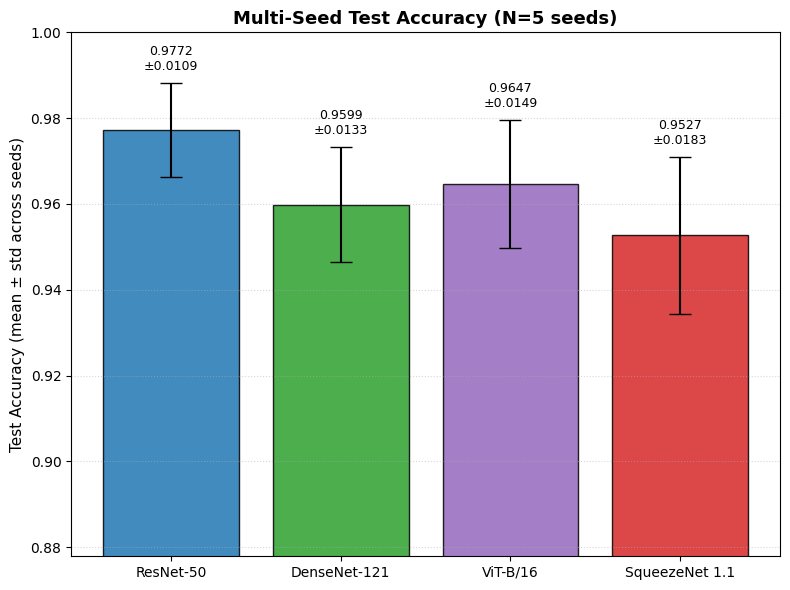

Saved to 'multiseed_accuracy_comparison.png'


In [ ]:
# 11. Mean +/- std accuracy plot across seeds, per model

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'ResNet-50': '#1f77b4', 'DenseNet-121': '#2ca02c', 'ViT-B/16': '#9467bd', 'SqueezeNet 1.1': '#d62728'}

means = [summary_df.loc[summary_df['Model'] == m, 'accuracy_mean'].values[0] for m in MODEL_LIST]
stds = [summary_df.loc[summary_df['Model'] == m, 'accuracy_std'].values[0] for m in MODEL_LIST]

ax.bar(MODEL_LIST, means, yerr=stds, capsize=8,
       color=[colors[m] for m in MODEL_LIST], alpha=0.85, edgecolor='black')
ax.set_ylabel('Test Accuracy (mean \u00b1 std across seeds)', fontsize=11)
ax.set_title(f'Multi-Seed Test Accuracy (N={len(SEEDS)} seeds)', fontsize=13, fontweight='bold')
ax.set_ylim(min(means) - 3 * max(stds) - 0.02, 1.0)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.003, f'{m:.4f}\n\u00b1{s:.4f}', ha='center', fontsize=9)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('multiseed_accuracy_comparison.png', dpi=300)
plt.show()
print("Saved to 'multiseed_accuracy_comparison.png'")

## Confusion Matrices (Primary Seed, All Four Models)

Inference-only — reuses `primary_models` and `primary_test_loaders` from the main loop
above, so no retraining is required. Shown row-normalized (each row sums to 1.0), so each
cell is the recall rate for that true class, with raw counts annotated underneath.

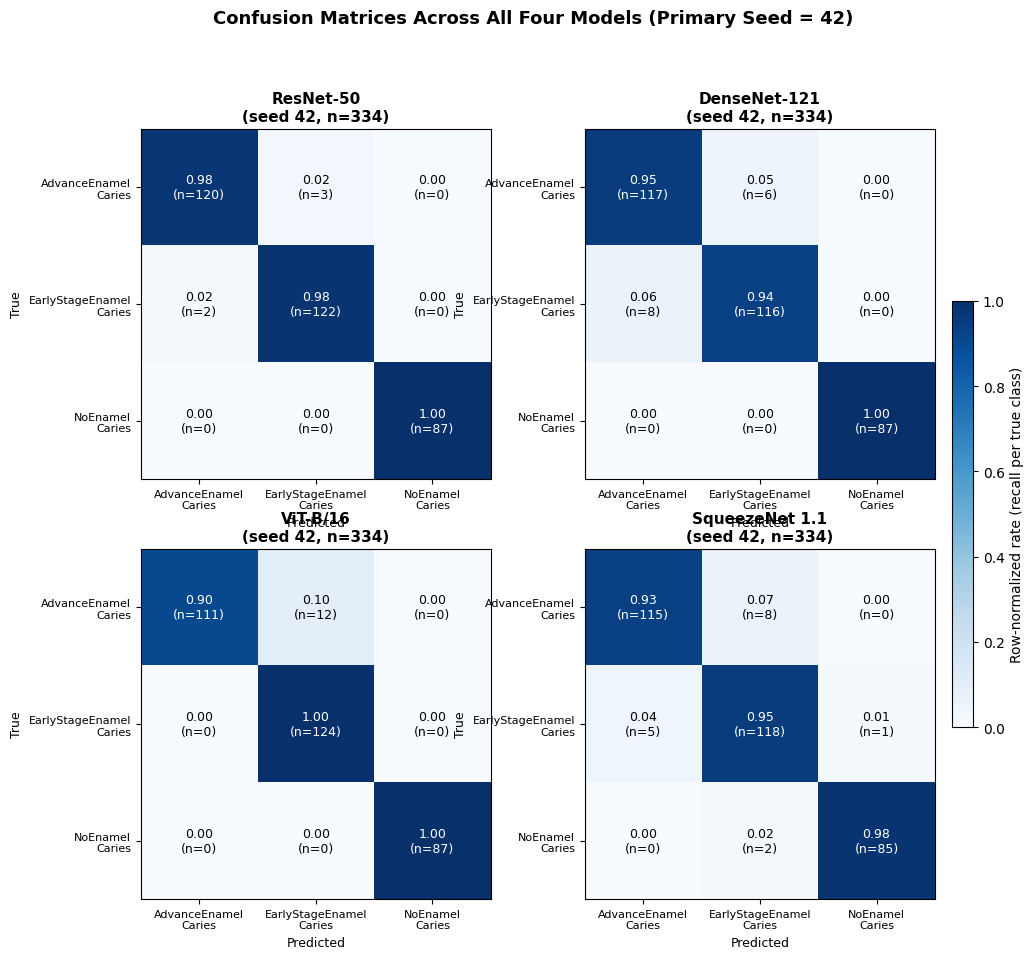

Saved to 'confusion_matrices_all_models.png'


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()
short_names = [n.replace('_', '\n') for n in CLASS_NAMES]

for ax, model_name in zip(axes, MODEL_LIST):
    model = primary_models[model_name]
    loader = primary_test_loaders[model_name]

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(CLASS_NAMES))))
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{model_name}\n(seed {PRIMARY_SEED}, n={cm.sum()})', fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(short_names, fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm_normalized[i, j]:.2f}\n(n={cm[i, j]})',
                     ha='center', va='center', color=color, fontsize=9)

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='Row-normalized rate (recall per true class)')
plt.suptitle(f'Confusion Matrices Across All Four Models (Primary Seed = {PRIMARY_SEED})',
             fontsize=13, fontweight='bold', y=1.00)
plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to 'confusion_matrices_all_models.png'")

## Explainability (Grad-CAM / Attention Rollout) — Primary Seed Only

Generated once, from the models trained under `PRIMARY_SEED`, to avoid producing N complete sets of explainability figures. As before, these reuse the already-trained model objects directly (no reinitialization).

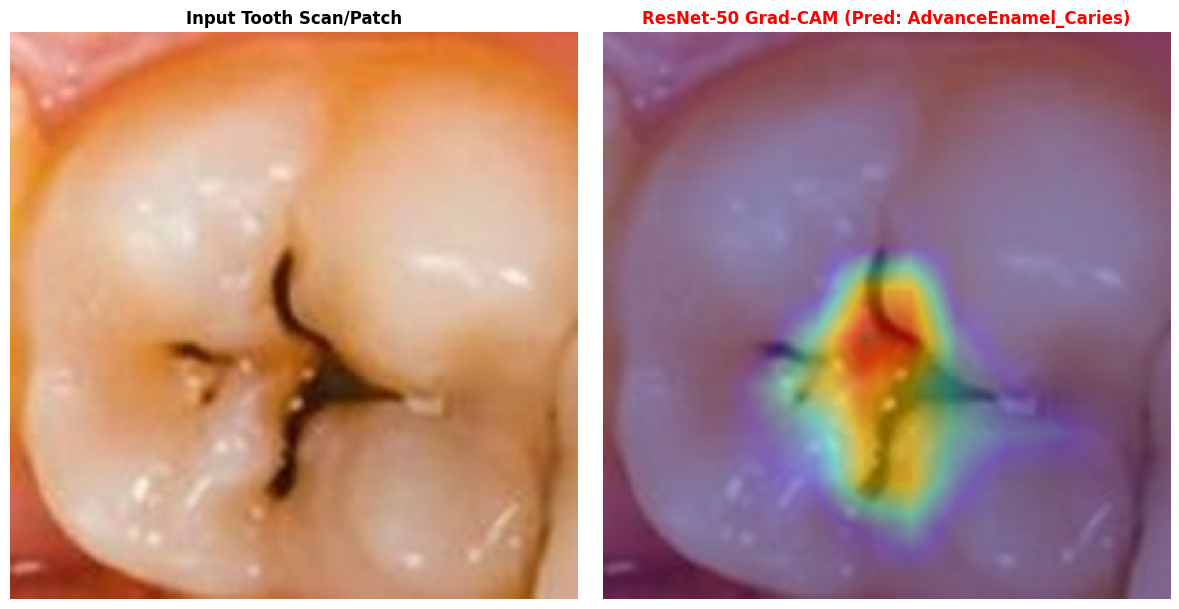

Grad-CAM saved to 'resnet_gradcam_multiseed.png'


In [ ]:
import cv2
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.features = None
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_full_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = torch.mean(self.gradients, dim=[2, 3])[0]
        cam = torch.zeros(self.features.shape[2:], dtype=torch.float32, device=self.features.device)
        for i, w in enumerate(weights):
            cam += w * self.features[0, i, :, :]
        cam = np.maximum(cam.cpu().numpy(), 0)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        return cam, class_idx


def run_gradcam(model, target_layer, img_path, resolution, title, save_path, cmap_title_color='red'):
    cam_extractor = GradCAM(model, target_layer)
    raw_image = Image.open(img_path).convert('RGB')
    orig_w, orig_h = raw_image.size

    preprocess = transforms.Compose([
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(raw_image).unsqueeze(0).to(device)

    heatmap, predicted_class_idx = cam_extractor.generate_heatmap(input_tensor)
    heatmap_resized = cv2.resize(heatmap, (orig_w, orig_h))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    blended_img = cv2.addWeighted(np.array(raw_image), 0.6, heatmap_color, 0.4, 0)
    pred_label = CLASS_NAMES[predicted_class_idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(raw_image)
    axes[0].set_title("Input Tooth Scan/Patch", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(blended_img)
    axes[1].set_title(f"{title} (Pred: {pred_label})", fontsize=12, fontweight='bold', color=cmap_title_color)
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Grad-CAM saved to '{save_path}'")


IMG_PATH = f'{DATA_DIR}/AdvanceEnamel_Caries/AdvanceEnamel_Caries_001.jpg'

run_gradcam(primary_models['ResNet-50'], primary_models['ResNet-50'].layer4[-1], IMG_PATH,
            resolution=384, title="ResNet-50 Grad-CAM", save_path='resnet_gradcam_multiseed.png')

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


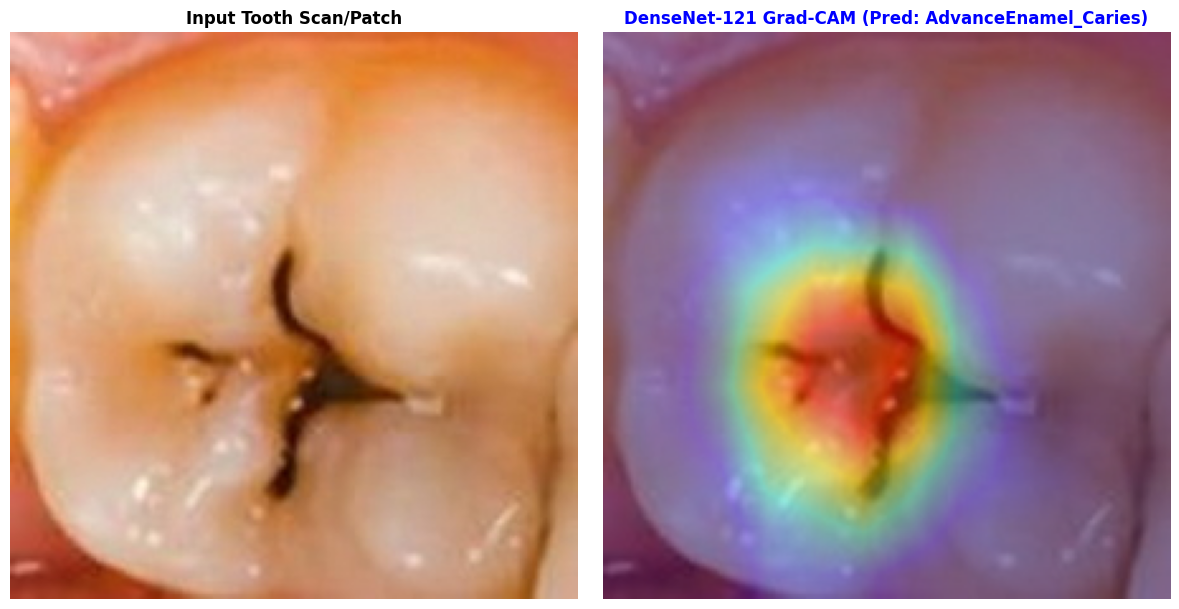

Grad-CAM saved to 'densenet_gradcam_multiseed.png'


In [ ]:
target_layer = list(primary_models['DenseNet-121'].features.denseblock4.children())[-1]
run_gradcam(primary_models['DenseNet-121'], target_layer, IMG_PATH, resolution=384,
            title="DenseNet-121 Grad-CAM", save_path='densenet_gradcam_multiseed.png', cmap_title_color='blue')

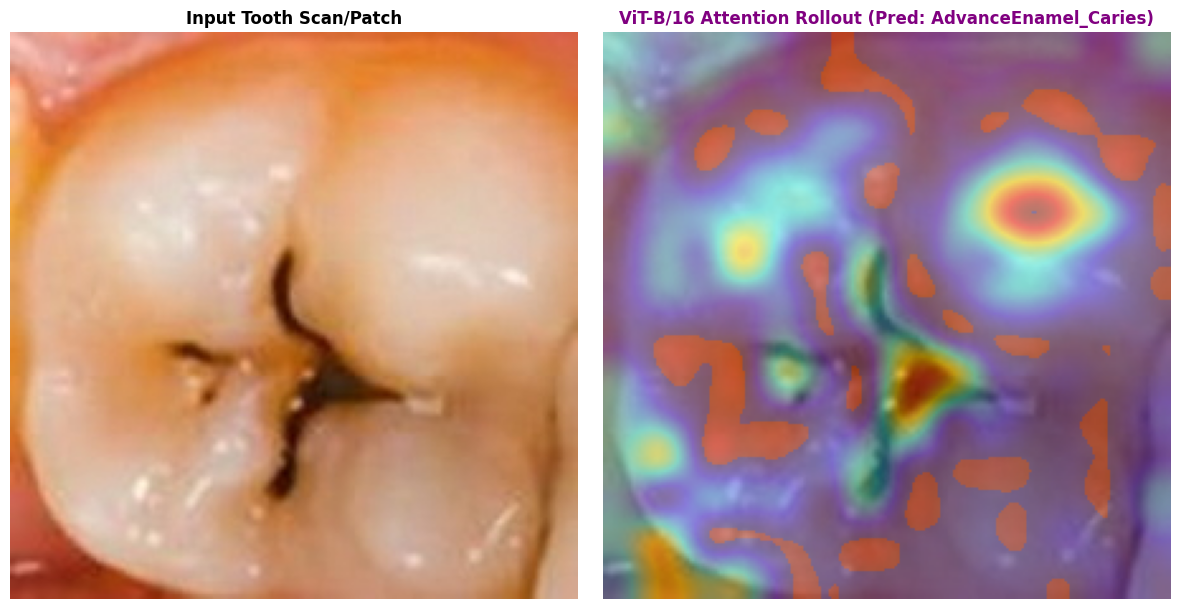

Saved to 'vit_attention_rollout_multiseed.png'


In [ ]:
class ViTRollout:
    def __init__(self, model, discard_ratio=0.8, head_fusion="mean"):
        self.model = model
        self.discard_ratio = discard_ratio
        self.head_fusion = head_fusion
        self.attentions = []

    def rollout(self, input_tensor):
        self.model.eval()
        self.attentions = []

        n = input_tensor.shape[0]
        x = self.model._process_input(input_tensor)
        batch_class_token = self.model.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.model.encoder.dropout(x)

        for layer in self.model.encoder.layers:
            x_norm = layer.ln_1(x)
            attn_output, attn_weights = layer.self_attention(x_norm, x_norm, x_norm, need_weights=True)
            self.attentions.append(attn_weights.detach())
            x = x + layer.dropout(attn_output)
            x_norm_mlp = layer.ln_2(x)
            x = x + layer.mlp(x_norm_mlp)

        with torch.no_grad():
            full_model_output = self.model(input_tensor)
            predicted_class_idx = torch.argmax(full_model_output, dim=1).item()

        attentions_stacked = torch.stack(self.attentions).squeeze(1)
        num_tokens = attentions_stacked.size(-1)
        result = torch.eye(num_tokens, device=input_tensor.device)

        for attention in attentions_stacked:
            if self.head_fusion == "mean":
                attention_heads_fused = torch.mean(attention, dim=0)
            elif self.head_fusion == "max":
                attention_heads_fused = torch.max(attention, dim=0).values

            flat = attention_heads_fused.view(-1)
            if flat.numel() > 0:
                topk_count = int(flat.numel() * self.discard_ratio)
                if 0 < topk_count < flat.numel():
                    _, indices = flat.topk(topk_count, -1, largest=False)
                    flat[indices] = 0

            I = torch.eye(num_tokens, device=input_tensor.device)
            a = (attention_heads_fused + I) / 2
            sum_val = a.sum(dim=-1, keepdim=True)
            a = a / (sum_val + 1e-6)
            result = torch.matmul(a, result)

        mask = result[0, 1:]
        grid_size = int(np.sqrt(mask.size(0)))
        mask = mask.reshape(grid_size, grid_size).cpu().numpy()
        if np.max(mask) != 0:
            mask = mask / np.max(mask)
        return mask, predicted_class_idx


rollout_engine = ViTRollout(primary_models['ViT-B/16'], discard_ratio=0.8, head_fusion="mean")

raw_image = Image.open(IMG_PATH).convert('RGB')
orig_w, orig_h = raw_image.size
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(raw_image).unsqueeze(0).to(device)

attention_mask, predicted_class_idx = rollout_engine.rollout(input_tensor)
attention_resized = cv2.resize(attention_mask, (orig_w, orig_h), interpolation=cv2.INTER_CUBIC)
attention_color = cv2.applyColorMap(np.uint8(255 * attention_resized), cv2.COLORMAP_JET)
attention_color = cv2.cvtColor(attention_color, cv2.COLOR_BGR2RGB)
blended_img = cv2.addWeighted(np.array(raw_image), 0.6, attention_color, 0.4, 0)
pred_label = CLASS_NAMES[predicted_class_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_image)
axes[0].set_title("Input Tooth Scan/Patch", fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(blended_img)
axes[1].set_title(f"ViT-B/16 Attention Rollout (Pred: {pred_label})", fontsize=12, fontweight='bold', color='purple')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('vit_attention_rollout_multiseed.png', dpi=300)
plt.show()
print("Saved to 'vit_attention_rollout_multiseed.png'")

Attempting to fix SqueezeNet 1.1 model by replacing in-place ReLUs...
SqueezeNet 1.1 model modified. Retrying Grad-CAM.


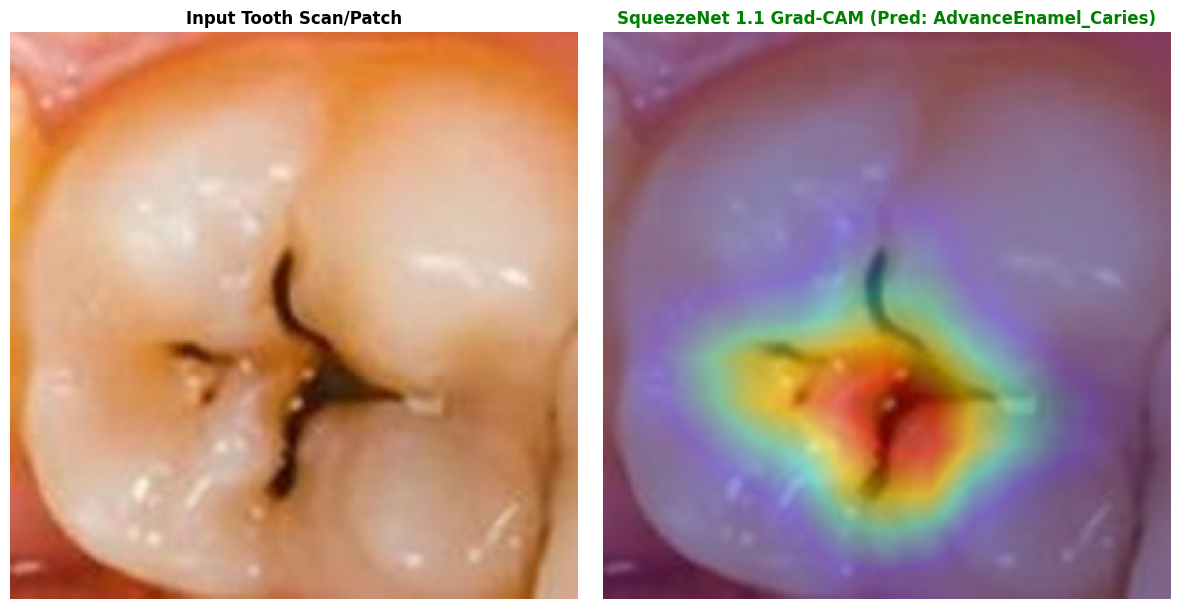

Grad-CAM saved to 'squeezenet_gradcam_multiseed.png'


In [ ]:
import cv2
from PIL import Image

# The GradCAM class is defined in a previous cell and cannot be modified directly here.
# The error "RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace."
# typically arises in PyTorch when a model uses `inplace=True` for activation functions (like ReLU).
# SqueezeNet from torchvision is known to use `inplace=True` in its ReLU layers.
# During the backward pass (gradient computation) that Grad-CAM requires, PyTorch's autograd engine
# cannot correctly track gradients through in-place operations on tensor views.

# To fix this, we need to modify the SqueezeNet model to use `inplace=False` for all its ReLU layers.
# We will define a helper function to recursively find and replace these layers.

def replace_inplace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            # Replace nn.ReLU(inplace=True) with nn.ReLU(inplace=False)
            # This creates a new ReLU module, ensuring operations are not in-place.
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            # Recursively apply to child modules
            replace_inplace_relu(child)

print("Attempting to fix SqueezeNet 1.1 model by replacing in-place ReLUs...")
squeezenet_model = primary_models['SqueezeNet 1.1']
replace_inplace_relu(squeezenet_model)
print("SqueezeNet 1.1 model modified. Retrying Grad-CAM.")

# Now, proceed with the Grad-CAM visualization using the modified model
target_layer = squeezenet_model.classifier[1] # The target layer remains the same
run_gradcam(squeezenet_model, target_layer, IMG_PATH, resolution=224,
            title="SqueezeNet 1.1 Grad-CAM", save_path='squeezenet_gradcam_multiseed.png', cmap_title_color='green')

## Notes for the paper

- State explicitly in Methods that 23 exact-duplicate images (11 groups) were identified via
  MD5 hashing and deduplicated prior to splitting -- this is a data-quality control step
  worth reporting, not just fixing silently.
- If the No-Caries class metrics or overall accuracy dropped compared to the
  non-deduplicated run, that's evidence the earlier numbers had some leakage-driven
  inflation; report both if you want to show the effect size of the fix transparently.
- Report **Table 1 as mean ± std** (cell 9's `display_df`), not single-run point estimates.
- Report the **pairwise p-values** (cell 9) alongside the accuracy table, and explicitly state
  which pairs of models are/aren't statistically distinguishable at p<0.05 with this seed count.
- If `SEEDS` was trimmed below 5 for runtime reasons, say so explicitly in Methods (N seeds is
  small enough that it materially affects statistical power).
- The explainability figures remain single-image qualitative illustrations (now from the
  primary seed only) — quantitative interpretability evaluation is still open future work.